# **Exploratory Data Analysis (EDA) and Regression**


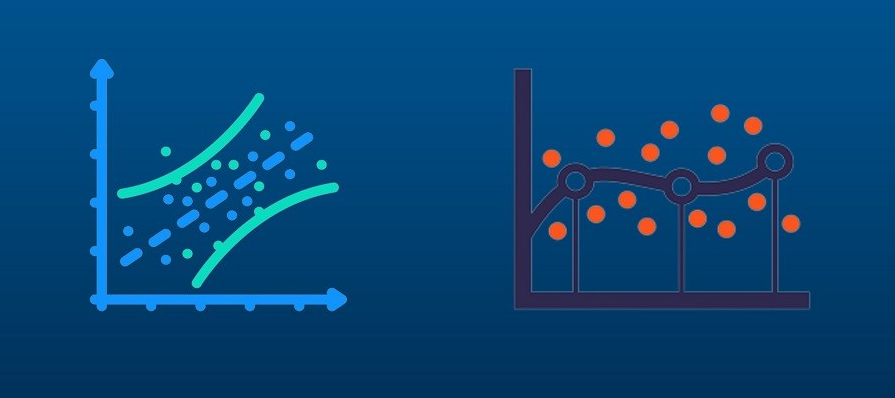

**คำจำกัดความ**

Regression Analysis เป็นวิธีการทางสถิติที่ใช้ในการวิเคราะห์ความสัมพันธ์ระหว่างตัวแปรอิสระ (predictors) และตัวแปรตาม (response) เพื่อทำนายตัวแปรตามจากตัวแปรอิสระ

- วิธีทางสถิติ
- ความสัมพันธ์ของตัวแปรที่เราสนใจตั้งแต่ 2 ตัวขึ้นไป
  - ความสัมพันธ์
    - linear
    - non-linear
  - ตัวแปร
    - continuous data
    - ตัวแปรอิสระ (predictors /independent variables)
      - univariable
      - multivariable
    - ตัวแปรตาม (response / dependent variable)
- การประยุกต์ใช้
  - finance, investing, data science, psychology, etc.

# 1 Linear Regression

<img src="https://vitalflux.com/wp-content/uploads/2020/09/Screenshot-2020-09-30-at-8.18.35-AM.png"><br>
image from: <a href="https://vitalflux.com/linear-regression-hypothesis-testing-examples/">Linear regression hypothesis testing: Concepts, Examples</a>

- by [<img src="https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png" height="32"/> scikit-learn (LinearRegression)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression)

## 1.1 แหล่งข้อมูล

- ใช้ dataset จากไฟล์ `data/insurance.csv`
  - [Dataset from kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)
  * **age**: อายุของผู้เอาประกัน
  * **sex**: เพศของผู้เอาประกัน (female, male)
  * **bmi**: ดัชนีมวลกาย $(\frac{kg}{m ^ 2})$, ค่าปกติจะอยู่ในช่วง 18.5 ถึง 24.9
  * **children**: จำนวนบุตร/ธิดา
  * **smoker**: สูบบุหรี่หรือไม่
  * **region**: เขตที่พักอาศัยในสหรัฐอเมริกา (northeast, southeast, southwest, northwest)
  * **charges**: ค่ารักษาพยาบาล
- อัพโหลดขึ้น Google Drive
- เรียกใช้ `pandas`
- สร้าง DataFrame จากไฟล์ `data/insurance.csv` โดยคลิ๊กขวาที่ชื่อไฟล์ แล้วเลือก `Copy path`
```python
import pandas as pd
ins_df = pd.read_csv('<file path>')
```

In [1]:
import pandas as pd
ins_df = pd.read_csv('data/insurance.csv')

## 1.1 แหล่งข้อมูล

- ใช้ dataset จากไฟล์ `data/insurance.csv`
  - [Dataset from kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)
  * **age**: อายุของผู้เอาประกัน
  * **sex**: เพศของผู้เอาประกัน (female, male)
  * **bmi**: ดัชนีมวลกาย $(\frac{kg}{m ^ 2})$, ค่าปกติจะอยู่ในช่วง 18.5 ถึง 24.9
  * **children**: จำนวนบุตร/ธิดา
  * **smoker**: สูบบุหรี่หรือไม่
  * **region**: เขตที่พักอาศัยในสหรัฐอเมริกา (northeast, southeast, southwest, northwest)
  * **charges**: ค่ารักษาพยาบาล
- อัพโหลดขึ้น Google Drive
- เรียกใช้ `pandas`
- สร้าง DataFrame จากไฟล์ `data/insurance.csv` โดยคลิ๊กขวาที่ชื่อไฟล์ แล้วเลือก `Copy path`
```python
import pandas as pd
ins_df = pd.read_csv('<file path>')
```

* ดูรายการสรุปของคอลัมน์ที่มี
```python
ins_df.info()
```

In [2]:
ins_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


* สำรวจค่าทางสถิติของคอลัมน์ต่างๆ
```python
ins_df.describe(include='all').T
```

In [3]:
ins_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


- แสดงเป็นแผนภาพ โดยใช้ matplotlib + seaborn
```python
import matplotlib.pyplot as plt
import seaborn as sns
```

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

- แสดงความสัมพันธ์ของแต่ละคู่ attributes (pair plot) จำแนกตาม sex
```python
sns.pairplot(ins_df, hue=?, corner=True)
```

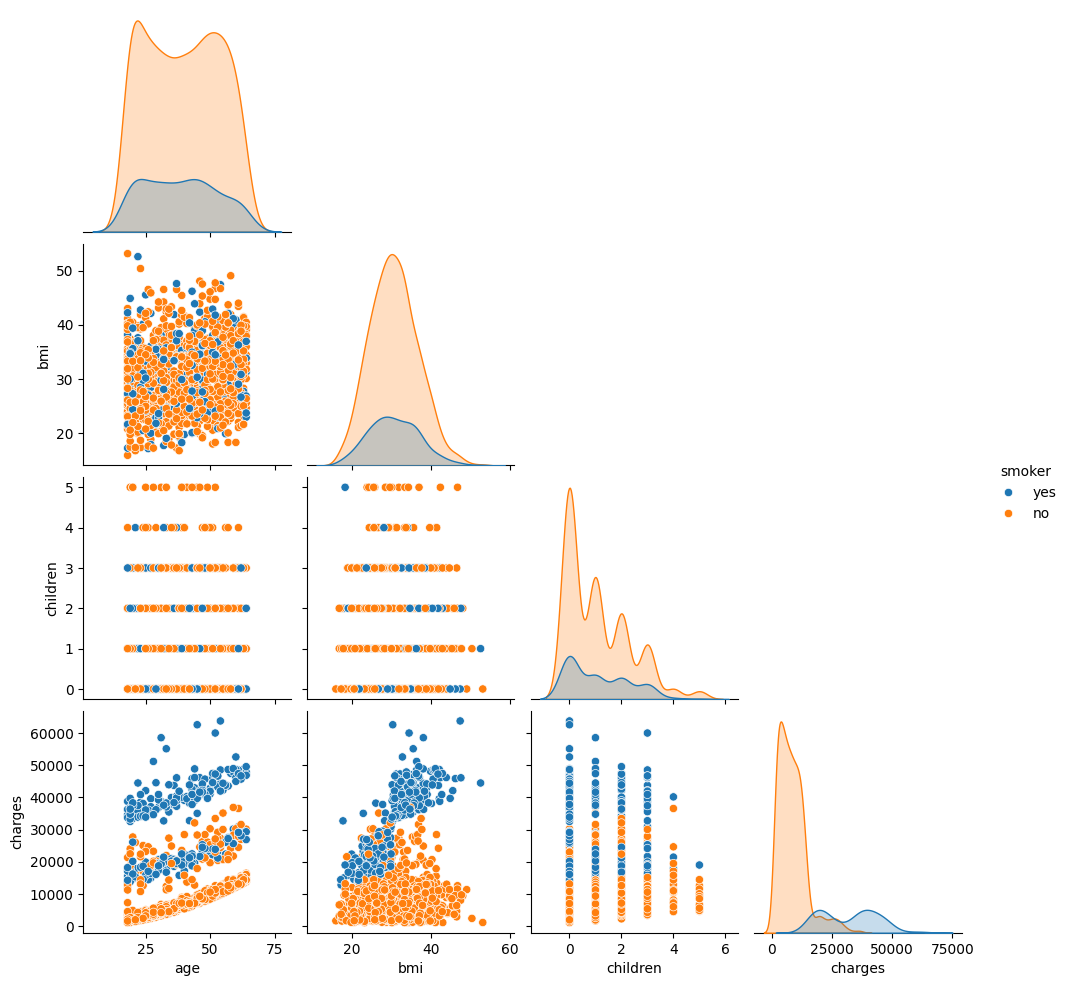

In [5]:
sns.pairplot(data=ins_df, hue='smoker', corner=True)

- แสดงความสัมพันธ์ของแต่ละคู่ attributes (pair plot) จำแนกตาม smaker

- แสดงความสัมพันธ์ของแต่ละคู่ attributes (pair plot) จำแนกตาม region

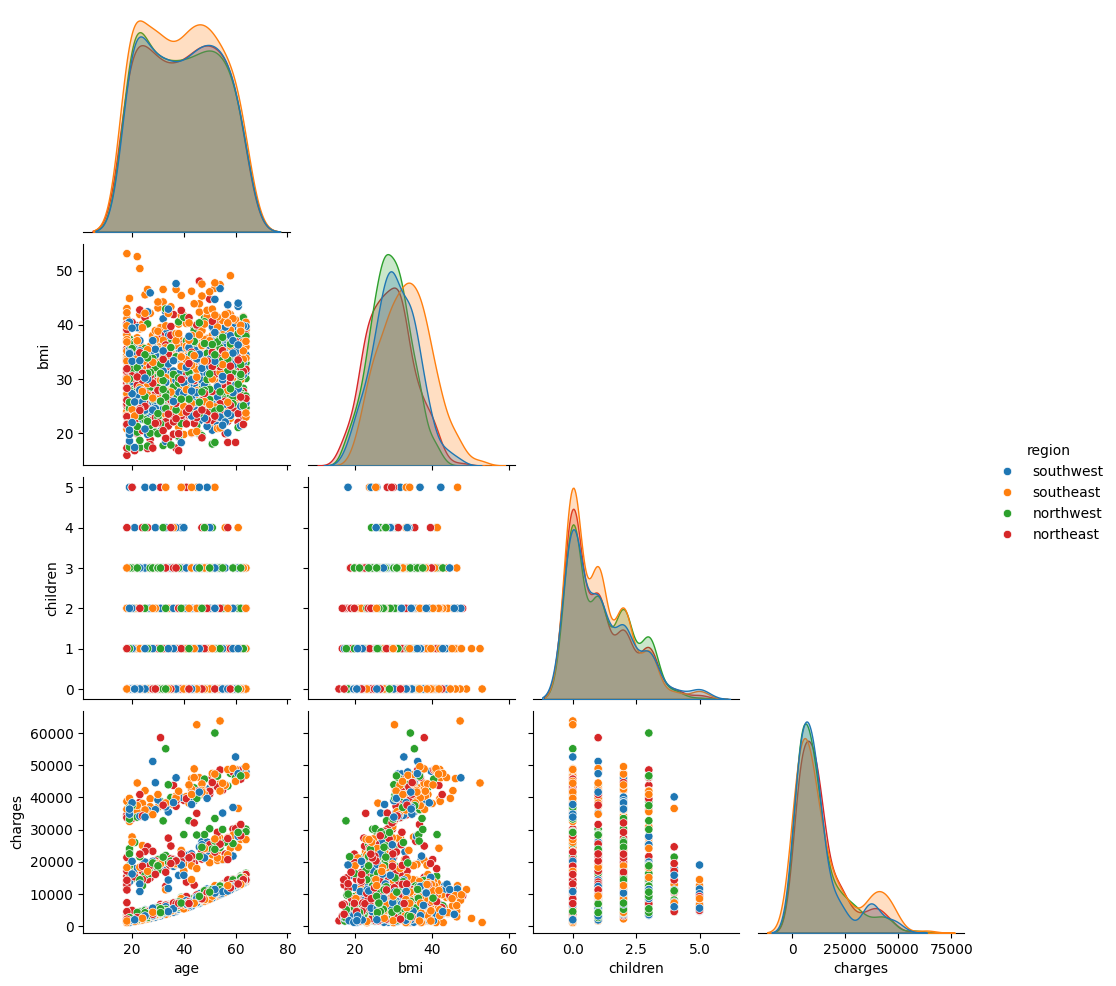

In [6]:
sns.pairplot(data=ins_df, hue='region', corner=True)

## 1.3 Simple Linear Regression

- $f(x) = mx + b$
- `Y = (coefficients * X) + intercept`
- **Coefficients (ค่าสัมประสิทธิ์)**: แสดงถึงความสัมพันธ์ระหว่างตัวแปรอิสระและตัวแปรตาม. หาก coefficient เป็นบวก หมายความว่าการเพิ่มขึ้นของตัวแปรอิสระจะทำให้ตัวแปรตามเพิ่มขึ้น และในทางกลับกัน
- **Intercept**: แสดงถึงค่าของตัวแปรตามเมื่อค่าของตัวแปรอิสระทั้งหมดเป็นศูนย์

### 1.3.1 การสร้างโมเดล

- เรียกใช้ `LinearRegression` library
```
from sklearn.linear_model import LinearRegression
```

In [7]:
from sklearn.linear_model import LinearRegression


- ในที่นี้ต้องการทำนาย `charges` ของคนสูบบุหรี่ จากค่า `bmi`
- กรองเอาเฉพาะข้อมูลของคนสูบบุหรี่
```python
smokers = ins_df[ins_df['smoker']=='yes']
```

In [8]:
smokers = ins_df[ins_df['smoker']=='yes']
smokers
ins_df['smoker'] == 'yes'

0        True
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337     True
Name: smoker, Length: 1338, dtype: bool

- สร้างโมเดล Linear Regression
```python
lr_model = LinearRegression()
```

In [9]:
lr_model = LinearRegression()



- เริ่มการเรียนรู้
```python
X = smokers[['bmi']]
y = smokers['charges']
lr_model.fit(X, y)
```

In [10]:
X = smokers[['bmi']]
y = smokers['charges']
lr_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- ดูผลลัพธ์ ค่า coefficients
```python
lr_model.coef_
```

In [11]:
lr_model.coef_

array([1473.1062547])

- ดูค่า intercept
```python
lr_model.intercept_
```

In [12]:
lr_model.intercept_

np.float64(-13186.576322762925)

### 1.3.2 การวัดประสิทธิภาพของโมเดล

- **R-squared ($R^2$)**: แสดงถึงสัดส่วนของความแปรปรวนในตัวแปรตามที่สามารถอธิบายได้โดยตัวแปรอิสระ. ค่า $R^2$ ใกล้เคียงกับ 1 หมายความว่าโมเดลมีประสิทธิภาพดี
  - $R^2 = 1-\frac{\sum(y_i-\hat{y})^2}{\sum(y_i-\bar{y})^2}$

- ดูค่า $R^2$
```python
lr_model.score(X, y)
```

In [13]:
lr_model.score(X,y)

0.6504109694921547

### 1.3.3 ใช้ model ในการทำนายผล

- สร้าง DataFrame ของค่าที่ต้องการทำนาย
```python
X_target = pd.DataFrame({'bmi': [24, 35]})
```

In [14]:
X_target = pd.DataFrame({'bmi': [24, 35]})
X_target

,bmi
0,24
1,35


- ทำนายผลจากชุดข้อมูล
```python
lr_model.predict(X_target)
```

In [15]:
lr_model.predict(X_target)


array([22167.97379007, 38372.14259179])

### 1.3.4 วาดกราฟแสดงโมเดลที่ได้

- หาค่า $Y'$ จากโมเดล
```python
y_predict = lr_model.predict(X)
```

In [16]:
y_predict = lr_model.predict(X)



- แสดงโมเดลในรูปของกราฟเส้น
```python
sns.scatterplot(x=smokers['bmi'], y=y)
sns.lineplot(x=smokers['bmi'], y=y_predict, color='red')
```

<Axes: xlabel='bmi', ylabel='charges'>

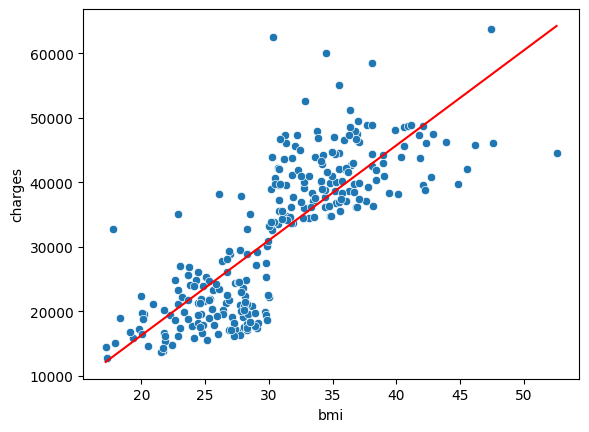

In [17]:
sns.scatterplot(x=smokers['bmi'], y=y)
sns.lineplot(x=smokers['bmi'], y=y_predict, color='red')

## 1.4 Multiple Linear Regression

- $f(x_1,x_2,...,x_n) = m_1x_1+m_2x_2+...+m_nx_n+b$
- `Y = (coefficients[0] * X[0]) + (coefficients[1] * X[1]) + ... + (coefficients[n] * X[n]) + intercept`

- ในที่นี้ต้องการทำนาย `charges` ของคนสูบบุหรี่ จากค่า `age` และ `bmi`

### 1.4.1 สร้างโมเดล

- ใช้โมเดล Linear Regression
```python
mlr_model = LinearRegression()
```

In [18]:
mlr_model = LinearRegression()



- เริ่มการเรียนรู้
```python
mX = smokers[['age', 'bmi']]
y = smokers['charges']
mlr_model.fit(mX, y)
```

In [19]:
mX = smokers[['age', 'bmi']]
y = smokers['charges']
mlr_model.fit(mX, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- ดูผลลัพธ์ ค่า coefficients

In [20]:
mlr_model.coef_

array([ 266.29222371, 1438.09098289])

- ดูค่า intercept

In [21]:
mlr_model.intercept_

np.float64(-22367.44972775126)

- ดูค่า $R^2$

In [22]:
mlr_model.score(mX,y)

0.7532402651740856

### 1.4.2 ใช้ model ในการทำนายผล

- สร้าง DataFrame ของค่าที่ต้องการทำนาย
```python
mX_target = pd.DataFrame({'age': [36, 28], 'bmi': [24, 35]})
```

In [23]:
mX_target = pd.DataFrame({'age': [36, 28], 'bmi': [24, 35]})

mX_target

,age,bmi
0,36,24
1,28,35


- ทำนายผลจากชุดข้อมูล

In [24]:
y_predict = mlr_model.predict(mX_target)
y_predict

array([21733.25391496, 35421.91693705])

### 1.4.3 วาดกราฟแสดงโมเดลที่ได้

- เรียกใช้ `plotly` เพื่อวาดกราฟ 3D
```python
import plotly.graph_objects as go
```

In [25]:
import plotly.graph_objects as go

- สร้างรูปกราฟ
```python
fig = go.Figure(data=[])
```
- วาดกราฟจุด
```python
go.Scatter3d(x=smokers['age'], y=smokers['bmi'], z=smokers['charges'], mode='markers')
```
- วาดกราฟระนาบ
```python
go.Mesh3d(x=smokers['age'], y=smokers['bmi'], z=mlr_model.predict(smokers[['age', 'bmi']]))
```
- กำหนดการแสดงผล
```python
fig.update_layout(
  scene={'xaxis_title':'Age', 'yaxis_title':'BMI', 'zaxis_title':'Charges'}, width=800, height=800
)
```

In [26]:
fig = go.Figure(data=[
    go.Scatter3d(x=smokers['age'], y=smokers['bmi'], z=smokers['charges'], mode='markers'),
    go.Mesh3d(x=smokers['age'], y=smokers['bmi'], z=mlr_model.predict(smokers[['age', 'bmi']]))
])


fig.update_layout(
  scene={'xaxis_title':'Age', 'yaxis_title':'BMI', 'zaxis_title':'Charges'}, width=800, height=800
)

# 2 Non-Linear Regression

<img src="https://miro.medium.com/v2/resize:fit:583/0*2D6ggOEjv0iIASCG.png">

- **Polynomial Function**
  - $f(x)=\beta_0+\beta_1x+\beta_2x^2+...\beta_nx^n$
- **Exponential Function**
  - $f(x)=\alpha^{(\beta x)}$
- **Logarithmic Function**
  - $f(x)=\alpha+\beta ln(x)$
- **Power Function**
  - $f(x)=\alpha x^\beta$
- **Sigmoid Function**
  - $f(x)=\frac{1}{1+e^{-\beta_1 (x-\beta_2)}}$
- etc.

## 2.1 เตรียมข้อมูล

- ใช้ dataset จากไฟล์ `data/mosquito_Indicator.csv`
  - [Dataset from kaggle](https://www.kaggle.com/datasets/kukuroo3/mosquito-indicator-in-seoul-korea)
  * **date**: ข้อมูลรายวันในช่วง 05/2016 ถึง 12/2019
  * **mosquito_Indicator**: จำนวนยุงต่อพื้นที่ใน Seoul, Korea
  * **rain**: ปริมาณน้ำฝน (mm)
  * **mean_T(℃)**: อุณหภูมิเฉลี่ย
  * **min_T(℃)**: อุณหภูมิต่ำสุด
  * **max_T(℃)**: อุณหภูมิสูงสุด
- อัพโหลดขึ้น Google Drive
- สร้าง DataFrame จากไฟล์ `data/mosquito_Indicator.csv` โดยคลิ๊กขวาที่ชื่อไฟล์ แล้วเลือก `Copy path`
```python
mos_df = pd.read_csv('<file path>')
```

In [27]:
mos_df = pd.read_csv('data/mosquito_Indicator.csv')

## 2.2 สำรวจข้อมูล

- แสดงความสัมพันธ์ของแต่ละคู่ attributes (pair plot)

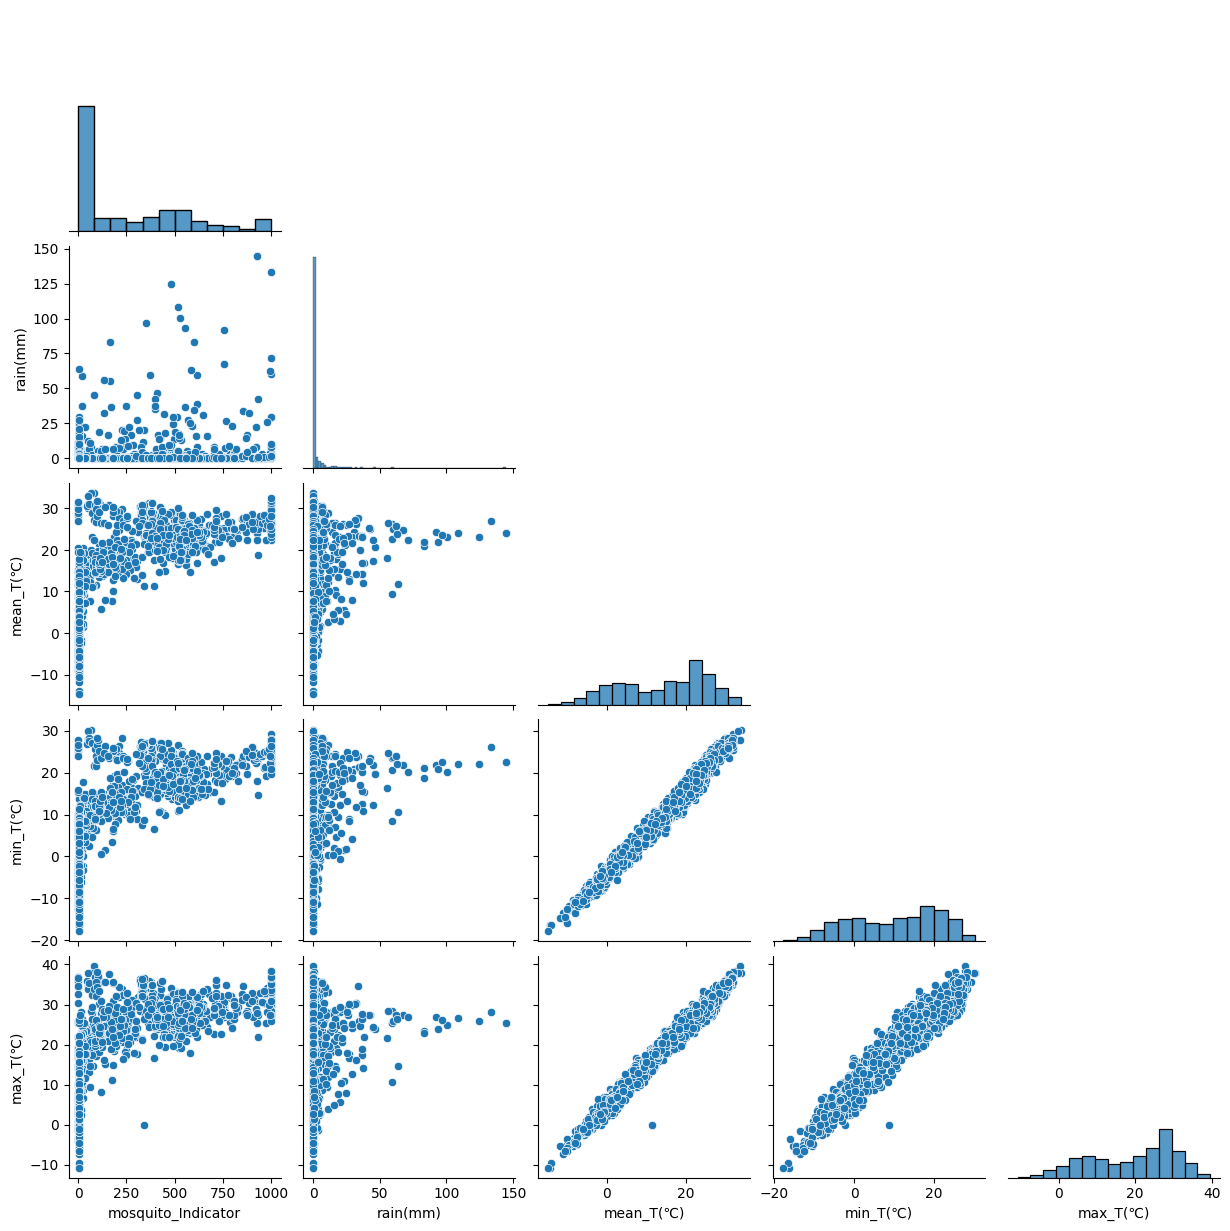

In [28]:
import seaborn as sns
_ = sns.pairplot(mos_df, corner=True)

- แสดงค่า corelation ของแต่ละคู่ attributes
```python
sns.heatmap(mos_df.drop('date', axis=1).corr(), annot=True)
```

<Axes: >

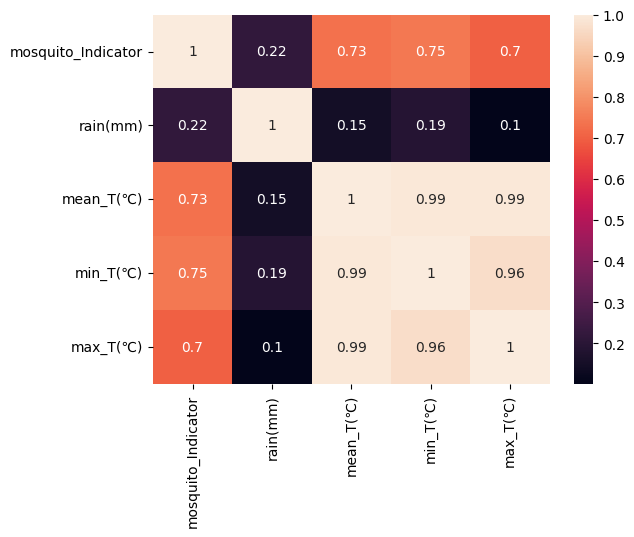

In [29]:
sns.heatmap(mos_df.drop('date', axis=1).corr(), annot=True)

- ข้อมูลที่เราสนใจ

<Axes: xlabel='min_T(℃)', ylabel='mosquito_Indicator'>

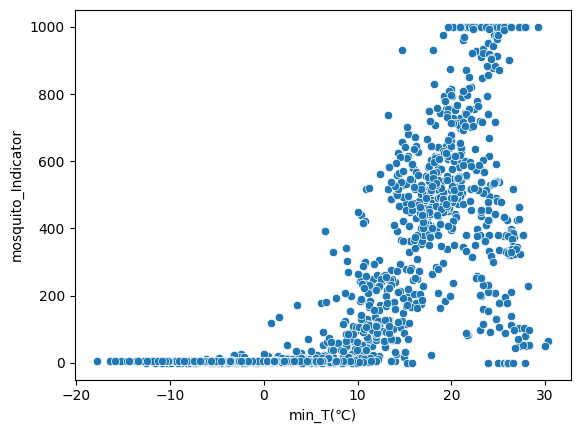

In [30]:
sns.scatterplot(mos_df, x='min_T(℃)', y='mosquito_Indicator')

## 2.3 สร้าง non-linear function (sigmoid)

- เรียกใช้ `numpy`
```python
import numpy as np
```

In [31]:
import numpy as np

- สร้างฟังก์ชัน sigmiod
```python
def sigmoid(x, beta_1, beta_2):
    y = 1 / (1 + np.exp(-beta_1 * (x - beta_2)))
    return y
```

In [32]:
def sigmoid(x, beta_1, beta_2):
    y = 1 / (1 + np.exp(-beta_1 * (x - beta_2)))
    return y

- เรียกใช้ `MinMaxScaler` เพื่อ normailze ข้อมูล
```python
from sklearn.preprocessing import MinMaxScaler
```

In [33]:
from sklearn.preprocessing import MinMaxScaler


- เรียกใช้ `MinMaxScaler` เพื่อ normailze ข้อมูล
```python
from sklearn.preprocessing import MinMaxScaler
```

- normalize ข้อมูลให้อยู่ในช่วง 0-1
```python
scaler = MinMaxScaler()
norm_data = scaler.fit_transform(mos_df[['min_T(℃)', 'mosquito_Indicator']]).T
```

In [34]:
scaler = MinMaxScaler()
norm_data = scaler.fit_transform(mos_df[['min_T(℃)', 'mosquito_Indicator']]).T
norm_data

array([[0.62370062, 0.71309771, 0.55509356, ..., 0.39293139, 0.25155925,
        0.14345114],
       [0.2544    , 0.2735    , 0.304     , ..., 0.0055    , 0.0055    ,
        0.0055    ]], shape=(2, 1342))

- เรียกใช้ `curve_fit`
```python
from scipy.optimize import curve_fit
```

In [35]:
from scipy.optimize import curve_fit

- ค้นหาพารามิเตอร์ที่ดีที่สุด
```python
beta, cov = curve_fit(sigmoid, norm_data[0], norm_data[1])
```

In [36]:
beta, cov = curve_fit(sigmoid, norm_data[0], norm_data[1])

beta

array([6.91091269, 0.7975604 ])

In [37]:
cov

array([[ 6.94063032e-02, -4.31346879e-04],
       [-4.31346879e-04,  2.15641307e-05]])

In [38]:
beta, cov = curve_fit(sigmoid, norm_data[0], norm_data[1])

beta

array([6.91091269, 0.7975604 ])

## 2.4 ใช้ model ในการทำนายผล

- สร้างชุดข้อมูลที่ต้องการทำนายผล
```python
target_df = pd.DataFrame({'min_T(℃)':[35], 'mosquito_Indicator': [0]})
```

In [39]:
target_df = pd.DataFrame({'min_T(℃)':[35], 'mosquito_Indicator': [0]})
target_df

,min_T(℃),mosquito_Indicator
0,35,0


- ทำ normailze
```python
target_norm = scaler.transform(target_df).T
```

In [40]:
target_norm = scaler.transform(target_df).T
target_norm

array([[1.0977131],
       [0.       ]])

- เรียกใช้ฟังก์ชัน sigmoid ด้วยพารามิเตอร์ที่ได้
```python
target_norm[1] = sigmoid(target_norm[0], *beta)
```

In [41]:
target_norm[1] = sigmoid(target_norm[0], *beta)


In [42]:
target_norm[1] = sigmoid(target_norm[0], *beta)
target_norm[1]

array([0.88838295])

- denormalize ชุดข้อมูลกลับเป็นค่าเดิม
```python
scaler.inverse_transform(target_norm.T)
```

In [43]:
scaler.inverse_transform(target_norm.T)


array([[ 35.        , 888.38295125]])

## 2.5 วาดกราฟแสดงโมเดลที่ได้

- denormalize ค่าทั้งหมด
```python
inv_norm = scaler.inverse_transform(np.array([norm_data[0], sigmoid(norm_data[0], *beta)]).T).T
```

In [44]:
inv_norm = scaler.inverse_transform(np.array([norm_data[0], sigmoid(norm_data[0], *beta)]).T).T

- วาดกราฟ
```python
sns.scatterplot(mos_df, x='min_T(℃)', y='mosquito_Indicator')
sns.lineplot(x=inv_norm[0], y=inv_norm[1], color='red')
```

<Axes: xlabel='min_T(℃)', ylabel='mosquito_Indicator'>

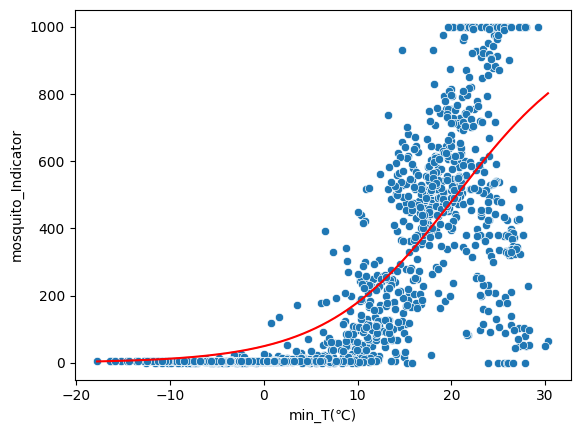

In [45]:
sns.scatterplot(mos_df, x='min_T(℃)', y='mosquito_Indicator')
sns.lineplot(x=inv_norm[0], y=inv_norm[1], color='red')

In [46]:
from sklearn.metrics import r2_score

In [47]:
r2_score(mos_df['mosquito_Indicator'], inv_norm[1])

0.5954992066773716